# Event Labeling + Pipeline (Futures)

A deterministic **synthetic** futures dataset (`make_synthetic_futures_dataset`, seed 7; generated in memory,
not market data) run through the AFML-style mid-frequency pipeline: CUSUM event sampling (AFML Ch. 2),
side/probability signals (Ch. 3 and 10), portfolio weights (Ch. 16) and risk checks (Ch. 14).

In [1]:
import nbfigures
import openquant
import polars as pl

ds = openquant.research.make_synthetic_futures_dataset(n_bars=192, seed=7)
out = openquant.pipeline.run_mid_frequency_pipeline_frames(
    timestamps=ds.timestamps,
    close=ds.close,
    model_probabilities=ds.model_probabilities,
    model_sides=ds.model_sides,
    asset_prices=ds.asset_prices,
    asset_names=ds.asset_names,
)
out["frames"]["events"].head()

start_ts,end_ts,prob,side
datetime[μs],datetime[μs],f64,f64
2024-01-01 09:32:00,2024-01-01 09:32:00,0.548463,1.0
2024-01-01 09:34:00,2024-01-01 09:34:00,0.571251,1.0
2024-01-01 09:37:00,2024-01-01 09:37:00,0.586007,1.0
2024-01-01 09:39:00,2024-01-01 09:39:00,0.589095,1.0
2024-01-01 09:42:00,2024-01-01 09:42:00,0.606304,1.0


In [2]:
assert out["frames"]["events"].height > 5
assert out["leakage_checks"]["inputs_aligned"] is True
summary = openquant.pipeline.summarize_pipeline(out)
summary

portfolio_sharpe,portfolio_return,portfolio_risk,realized_sharpe,value_at_risk,expected_shortfall,conditional_drawdown_risk,inputs_aligned,event_indices_sorted,has_forward_look_bias
f64,f64,f64,f64,f64,f64,f64,bool,bool,bool
20.032999,0.017616,0.000879,-0.136778,-0.000209,-0.000312,0.000768,true,true,false


## Where the CUSUM events fall

Each marker is a sampled event, drawn on the close series at the bar it fires. Filled markers are events the
model sides long, open markers short.

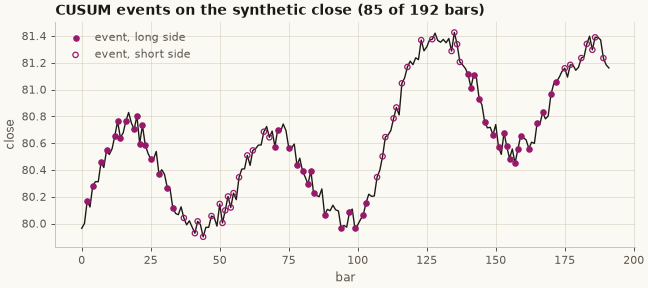

In [3]:
index_of = {ts: i for i, ts in enumerate(ds.timestamps)}
event_idx = [index_of[t] for t in out["events"]["timestamps"]]
event_side = list(out["events"]["sides"])
assert len(event_idx) == out["frames"]["events"].height


def draw(fig, c):
    ax = fig.subplots()
    ax.plot(range(len(ds.close)), ds.close, color=c["text"], linewidth=1.1)
    longs = [i for i, s in zip(event_idx, event_side) if s > 0]
    shorts = [i for i, s in zip(event_idx, event_side) if s < 0]
    ax.scatter(
        longs,
        [ds.close[i] for i in longs],
        s=18,
        color=c["accent"],
        label="event, long side",
        zorder=3,
    )
    ax.scatter(
        shorts,
        [ds.close[i] for i in shorts],
        s=18,
        facecolors="none",
        edgecolors=c["accent"],
        label="event, short side",
        zorder=3,
    )
    ax.set_title(f"CUSUM events on the synthetic close ({len(event_idx)} of {len(ds.close)} bars)")
    ax.set_xlabel("bar")
    ax.set_ylabel("close")
    ax.legend(loc="upper left")


nbfigures.figure(
    "nb01-cusum-events",
    draw,
    alt="Synthetic futures close series with the CUSUM-sampled events marked by model side.",
)

## Confusion diagnostics: model side vs. realised direction

At every event, compare the side the model proposed with the sign of the close-to-close move over the
next `HORIZON` bars. Rows are the realised direction, columns the predicted side.

In [4]:
HORIZON = 5
rows = []
for i, side in zip(event_idx, event_side):
    if i + HORIZON < len(ds.close):
        move = ds.close[i + HORIZON] - ds.close[i]
        rows.append({"actual": 1 if move > 0 else -1, "predicted": 1 if side > 0 else -1})
pairs = pl.DataFrame(rows)
confusion = (
    pairs.group_by(["actual", "predicted"])
    .len()
    .pivot(on="predicted", index="actual", values="len")
    .fill_null(0)
    .sort("actual")
    .select(["actual", "-1", "1"])  # pivot's column order follows group_by, which is unordered
)
accuracy = pairs.filter(pl.col("actual") == pl.col("predicted")).height / pairs.height
print(f"events scored: {pairs.height}, horizon: {HORIZON} bars, hit rate: {accuracy:.3f}")
confusion

events scored: 84, horizon: 5 bars, hit rate: 0.321


actual,-1,1
i64,u32,u32
-1,8,30
1,27,19
